# 영수증 텍스트 분류 (머신러닝 & 부스팅 모델)

이 노트북은 영수증 OCR 결과(JSON)를 **머신러닝 분류 모델**에 입력하기 위한 전처리 흐름과,
XGBoost / LightGBM 같은 **부스팅 기반 모델의 성능 비교**를 시각화하기 위한 데모용 노트북입니다.

PPT의 "머신러닝" 섹션에서 다음 내용을 시각적으로 보여줄 수 있도록 구성했습니다.

- 학습 데이터 구성 (Synthetic Data)
- 텍스트 데이터 전처리(벡터화, 레이블 인코딩, 불용어 제거)
- 부스팅 모델(XGBoost, LightGBM) 성능 비교
- 히스토그램 / 박스플롯 / 혼동 행렬 / 모델 비교 차트


In [1]:
# 라이브러리 로드 및 공통 설정

from pathlib import Path
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib

matplotlib.rcParams['font.family'] = ['NanumGothic', 'Malgun Gothic', 'DejaVu Sans']
matplotlib.rcParams['axes.unicode_minus'] = False

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
# 부스팅 모델 (XGBoost, LightGBM)
try:
    from xgboost import XGBClassifier
    HAS_XGBOOST = True
except ImportError:
    HAS_XGBOOST = False
    print("[경고] XGBoost가 설치되어 있지 않아 해당 모델은 생략됩니다. (pip install xgboost)")

try:
    from lightgbm import LGBMClassifier
    HAS_LIGHTGBM = True
except ImportError:
    HAS_LIGHTGBM = False
    print("[경고] LightGBM이 설치되어 있지 않아 해당 모델은 생략됩니다. (pip install lightgbm)")

# 한글 폰트 설정
matplotlib.rcParams['font.family'] = ['Malgun Gothic', 'NanumGothic', 'DejaVu Sans']
matplotlib.rcParams['axes.unicode_minus'] = False

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
DATA = ROOT / "data"
FIG_DIR = DATA / "outputs" / "ml_report"
FIG_DIR.mkdir(parents=True, exist_ok=True)

np.random.seed(42)

print("ROOT:", ROOT)
print("FIG_DIR:", FIG_DIR)


ROOT: d:\VScode\smartBudget\smartbudget\AI-service\OCR_receipts
FIG_DIR: d:\VScode\smartBudget\smartbudget\AI-service\OCR_receipts\data\outputs\ml_report


## 1. Synthetic Data(더미 데이터) 생성

OCR 결과와 동일한 JSON 포맷을 가정한 더미 영수증 데이터를 약 **4,000건** 생성합니다.

- 상호명: 카테고리별로 자주 등장하는 가맹점 이름
- 품목명: 카테고리별로 자주 등장하는 품목 이름
- 카테고리: `식비`, `교통비`, `문화생활`, `쇼핑`, `기타`


In [2]:
import numpy as np
import pandas as pd

# 1. 이미지(image_9ae16e)에 명시된 13개 카테고리 정의
categories = [
    "식비", "교통비", "생활용품", "통신비", "주거", 
    "건강", "꾸밈비", "교육", "경조사", "보험", 
    "여행", "자기계발", "기타"
]

# 2. 각 카테고리별 맞춤형 상호명(Merchant) 데이터 확장
merchant_by_cat = {
    "식비": ["이상구 베이커리", "한가득 분식", "참맛 김밥", "스타벅스", "맥도날드", "마켓컬리"],
    "교통비": ["서울택시", "시내버스", "카카오T", "코레일", "SK에너지", "GS칼칼텍스"],
    "생활용품": ["다이소", "올리브영", "홈플러스", "이마트", "쿠팡", "무신사"],
    "통신비": ["SK텔레콤", "KT", "LG유플러스", "알뜰폰허브"],
    "주거": ["관리비고지서", "한국전력공사", "도시가스", "다방", "직방"],
    "건강": ["서울대학병원", "행복약국", "정관장", "필라테스 스튜디오", "보건소"],
    "꾸밈비": ["준오헤어", "네일아트샵", "자라(ZARA)", "나이키", "미용실"],
    "교육": ["메가스터디", "영어학원", "구몬학습", "대학교등록금"],
    "경조사": ["OO장례식장", "XX결혼식장", "화환배달"],
    "보험": ["삼성화재", "현대해상", "교보생명", "국민건강보험"],
    "여행": ["제주항공", "아고다", "에어비앤비", "신라호텔", "렌터카"],
    "자기계발": ["교보문고", "패스트캠퍼스", "유데미", "독서실"],
    "기타": ["동사무소", "무인복합기", "복권판매점", "기타 서비스점"]
}

# 3. 각 카테고리별 맞춤형 품목명(Items) 데이터 확장
items_by_cat = {
    "식비": ["아메리카노", "샌드위치", "불고기버거", "모듬초밥", "식재료"],
    "교통비": ["버스운임", "택시비", "하이패스충전", "주유비", "KTX예매"],
    "생활용품": ["물티슈", "세제", "멀티탭", "샴푸", "주방도구"],
    "통신비": ["휴대폰요금", "인터넷사용료", "결합상품결제"],
    "주거": ["전기료", "수도세", "월세", "청소용품"],
    "건강": ["진료비", "멀티비타민", "감기약", "PT 10회권"],
    "꾸밈비": ["커트", "염색", "티셔츠", "운동화", "화장품"],
    "교육": ["학원수강료", "교재비", "온라인강의권"],
    "경조사": ["축의금", "조의금", "화환"],
    "보험": ["실손보험료", "자동차보험", "생명보험"],
    "여행": ["항공권", "숙박료", "투어입장권", "렌트비"],
    "자기계발": ["수험서", "온라인코딩강좌", "자격증응시료"],
    "기타": ["수수료", "기부금", "증명서발급"]
}

# 4. 현실적인 분포를 위한 가중치 설정 (식비와 쇼핑이 가장 빈번함)
# 총 합이 1이 되도록 설정
category_probs = [0.25, 0.15, 0.1, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05]

def generate_synthetic_receipts(n_samples: int = 10000) -> list[dict]:
    """확장된 카테고리를 바탕으로 10,000개의 더미 데이터 생성."""
    records = []
    for i in range(n_samples):
        cat = np.random.choice(categories, p=category_probs)
        merchant = np.random.choice(merchant_by_cat[cat])
        
        # 품목 개수는 1개에서 4개 사이 랜덤
        n_items = np.random.randint(1, 5)
        item_names = list(np.random.choice(items_by_cat[cat], size=n_items, replace=True))

        record = {
            "id": f"synthetic_{i:05d}",
            "merchant": merchant,
            "items": [{"name": name} for name in item_names],
            "category": cat,
        }
        records.append(record)
    return records

# 데이터 생성 (10,000개)
synthetic_json = generate_synthetic_receipts(n_samples=10000)

# DataFrame 변환
rows = []
for r in synthetic_json:
    rows.append({
        "id": r["id"],
        "merchant": r["merchant"],
        "items": " ".join(item["name"] for item in r["items"]),
        "category": r["category"],
    })

ml_df = pd.DataFrame(rows)
print(f"✅ 생성된 데이터 샘플 수: {len(ml_df)}")
print(ml_df['category'].value_counts()) # 카테고리별 분포 확인
ml_df.head()

✅ 생성된 데이터 샘플 수: 10000
category
식비      2516
교통비     1545
생활용품     920
꾸밈비      538
보험       532
통신비      529
교육       504
자기계발     504
기타       495
주거       486
건강       484
경조사      476
여행       471
Name: count, dtype: int64


,id,merchant,items,category
0,synthetic_00000,SK에너지,하이패스충전 KTX예매 KTX예매,교통비
1,synthetic_00001,참맛 김밥,불고기버거 불고기버거 식재료,식비
2,synthetic_00002,정관장,진료비 멀티비타민,건강
3,synthetic_00003,영어학원,교재비 학원수강료,교육
4,synthetic_00004,행복약국,진료비 PT 10회권,건강


## 2. 텍스트 전처리 (벡터화, 레이블 인코딩, 불용어 제거)

텍스트 JSON 데이터를 **머신러닝이 이해할 수 있는 숫자 피처**로 바꾸는 단계입니다.

- 상호명 + 품목명을 하나의 문장으로 합치고
- `주식회사`, `(주)`, `점` 등 의미 없는 상호 관련 불용어를 제거한 뒤
- `TF-IDF 벡터화`로 숫자 피처로 변환하고
- 카테고리 라벨을 `LabelEncoder`로 0/1/2... 숫자로 변환합니다.


In [3]:
# 텍스트 전처리

stopwords = ["주식회사", "(주)", "유한회사", "점", "지점", "코리아", "KR"]


def clean_text(text: str) -> str:
    text = str(text)
    for sw in stopwords:
        text = text.replace(sw, " ")
    # 공백 정리
    text = " ".join(text.split())
    return text


# 상호 + 품목명 결합 → 전처리 텍스트
ml_df["text"] = (
    ml_df["merchant"].fillna("")
    + " "
    + ml_df["items"].fillna("")
).apply(clean_text)

# 텍스트 길이(문자 수) → 박스플롯용 피처
ml_df["text_len"] = ml_df["text"].str.len()

# 레이블 인코딩 (카테고리 → 0,1,2,...)
label_encoder = LabelEncoder()
ml_df["label"] = label_encoder.fit_transform(ml_df["category"])

print("라벨 매핑 (index → category):")
for idx, name in enumerate(label_encoder.classes_):
    print(f"  {idx}: {name}")

# 학습/검증 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(
    ml_df["text"],
    ml_df["label"],
    test_size=0.2,
    random_state=42,
    stratify=ml_df["label"],
)

# TF-IDF 벡터화 (단어/bi-gram 기준)
vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print("학습 샘플 수:", X_train_tfidf.shape[0])
print("피처 수 (TF-IDF 차원 수):", X_train_tfidf.shape[1])


라벨 매핑 (index → category):
  0: 건강
  1: 경조사
  2: 교육
  3: 교통비
  4: 기타
  5: 꾸밈비
  6: 보험
  7: 생활용품
  8: 식비
  9: 여행
  10: 자기계발
  11: 주거
  12: 통신비
학습 샘플 수: 8000
피처 수 (TF-IDF 차원 수): 571


## 3. 데이터 분포 / 이상치 시각화 (히스토그램 & 박스플롯)

머신러닝 보고서에 꼭 들어가는 **데이터 분석용 시각화**입니다.

- 히스토그램: 카테고리별 샘플 수 분포
- 박스플롯: 카테고리별 텍스트 길이 분포(이상하게 긴 상호명/품목 조합 탐지)

이 셀에서 생성된 PNG 이미지는 `data/outputs/ml_report` 폴더에 저장되며, PPT에 그대로 삽입할 수 있습니다.


findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Fon

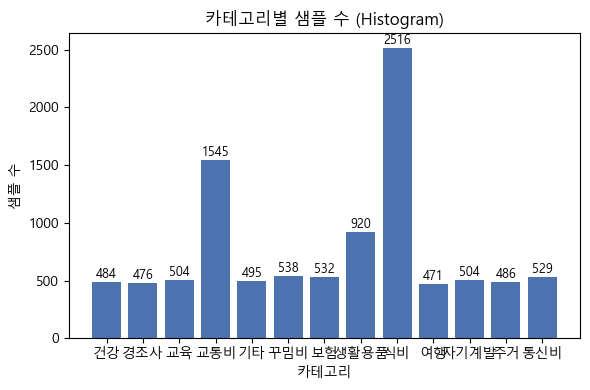

히스토그램 이미지 저장: d:\VScode\smartBudget\smartbudget\AI-service\OCR_receipts\data\outputs\ml_report\category_histogram.png


findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Fon

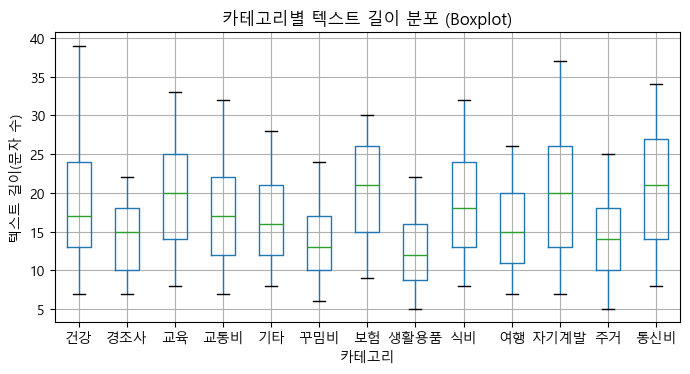

박스플롯 이미지 저장: d:\VScode\smartBudget\smartbudget\AI-service\OCR_receipts\data\outputs\ml_report\text_length_boxplot.png


In [4]:
# 히스토그램 & 박스플롯

# ① 카테고리 분포 히스토그램 (실제로는 막대그래프)
cat_counts = ml_df["category"].value_counts().sort_index()

fig1, ax1 = plt.subplots(figsize=(6, 4))
ax1.bar(cat_counts.index, cat_counts.values, color="#4C72B0")
ax1.set_title("카테고리별 샘플 수 (Histogram)")
ax1.set_xlabel("카테고리")
ax1.set_ylabel("샘플 수")
for i, v in enumerate(cat_counts.values):
    ax1.text(i, v + 10, str(v), ha="center", va="bottom", fontsize=9)
plt.tight_layout()
fig1_path = FIG_DIR / "category_histogram.png"
fig1.savefig(fig1_path, dpi=200, bbox_inches="tight")
plt.show()

print("히스토그램 이미지 저장:", fig1_path)

# ② 텍스트 길이 박스플롯
fig2, ax2 = plt.subplots(figsize=(7, 4))
ml_df.boxplot(column="text_len", by="category", ax=ax2)
ax2.set_title("카테고리별 텍스트 길이 분포 (Boxplot)")
ax2.set_xlabel("카테고리")
ax2.set_ylabel("텍스트 길이(문자 수)")
plt.suptitle("")  # pandas가 자동으로 넣는 제목 제거
plt.tight_layout()
fig2_path = FIG_DIR / "text_length_boxplot.png"
fig2.savefig(fig2_path, dpi=200, bbox_inches="tight")
plt.show()

print("박스플롯 이미지 저장:", fig2_path)


## 4. 분류 모델 학습 (Baseline vs XGBoost vs LightGBM)

- Baseline: 로지스틱 회귀, 랜덤 포레스트 등 간단한 모델
- Boosting: XGBoost, LightGBM 추가

각 모델의 **Accuracy**와 **학습 시간**을 함께 비교해서
"단순 모델보다 부스팅 기반 앙상블 모델이 더 높은 정확도를 보인다"는 메시지를 PPT에서 강조할 수 있습니다.


In [5]:
# 분류 모델 학습 및 성능 비교

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

models: list[tuple[str, object]] = []

# Baseline 모델들
models.append(
    (
        "LogisticRegression",
        LogisticRegression(max_iter=200, n_jobs=-1),
    )
)
models.append(
    (
        "RandomForest",
        RandomForestClassifier(n_estimators=200, max_depth=None, n_jobs=-1, random_state=42),
    )
)

# 부스팅 모델들 (라이브러리가 설치되어 있을 때만 추가)
if HAS_XGBOOST:
    models.append(
        (
            "XGBoost",
            XGBClassifier(
                n_estimators=300,
                learning_rate=0.1,
                max_depth=6,
                subsample=0.9,
                colsample_bytree=0.9,
                objective="multi:softprob",
                eval_metric="mlogloss",
                random_state=42,
                n_jobs=-1,
            ),
        )
    )

if HAS_LIGHTGBM:
    models.append(
        (
            "LightGBM",
            LGBMClassifier(
                n_estimators=300,
                learning_rate=0.1,
                max_depth=-1,
                subsample=0.9,
                colsample_bytree=0.9,
                random_state=42,
                n_jobs=-1,
            ),
        )
    )

results = []

best_acc = -1.0
best_model = None
best_name = None
best_pred = None

for name, model in models:
    print("\n===", name, "===")
    start = time.time()
    model.fit(X_train_tfidf, y_train)
    train_time = time.time() - start

    y_pred = model.predict(X_test_tfidf)
    acc = accuracy_score(y_test, y_pred)

    print(f"Accuracy: {acc:.4f}")
    print(f"Train time: {train_time:.3f} 초")
    print("\n분류 리포트:\n")
    print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

    results.append(
        {
            "model": name,
            "accuracy": acc,
            "train_time_sec": train_time,
        }
    )

    if acc > best_acc:
        best_acc = acc
        best_model = model
        best_name = name
        best_pred = y_pred

print("\n최고 성능 모델:", best_name, f"(Accuracy={best_acc:.4f})")



=== LogisticRegression ===
Accuracy: 1.0000
Train time: 3.771 초

분류 리포트:

              precision    recall  f1-score   support

          건강       1.00      1.00      1.00        97
         경조사       1.00      1.00      1.00        95
          교육       1.00      1.00      1.00       101
         교통비       1.00      1.00      1.00       309
          기타       1.00      1.00      1.00        99
         꾸밈비       1.00      1.00      1.00       108
          보험       1.00      1.00      1.00       106
        생활용품       1.00      1.00      1.00       184
          식비       1.00      1.00      1.00       503
          여행       1.00      1.00      1.00        94
        자기계발       1.00      1.00      1.00       101
          주거       1.00      1.00      1.00        97
         통신비       1.00      1.00      1.00       106

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000


===

## 5. 혼동 행렬(Confusion Matrix)

어떤 카테고리를 어떤 카테고리로 헷갈려 하는지 한눈에 보여주는 표입니다.

- 행: 실제 카테고리
- 열: 모델이 예측한 카테고리

PPT에서 분류 모델 설명 시 **필수 지표 이미지**로 활용할 수 있습니다.


findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Fon

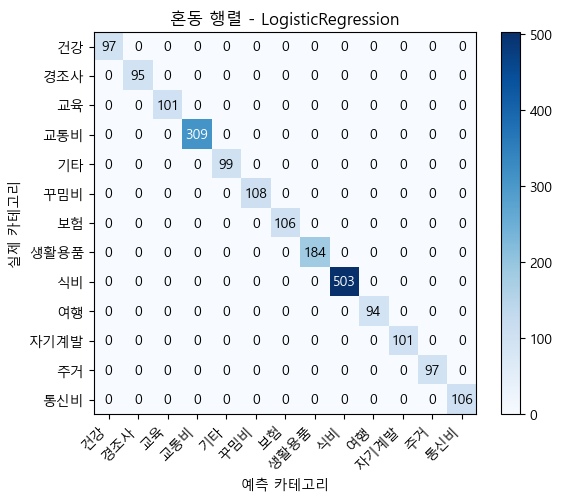

혼동 행렬 이미지 저장: d:\VScode\smartBudget\smartbudget\AI-service\OCR_receipts\data\outputs\ml_report\confusion_matrix_best_model.png


In [6]:
# 최고 성능 모델의 혼동 행렬

if best_pred is None:
    raise RuntimeError("먼저 모델 학습 셀을 실행해 best_model / best_pred를 생성하세요.")

cm = confusion_matrix(y_test, best_pred)
classes = label_encoder.classes_

fig_cm, ax_cm = plt.subplots(figsize=(6, 5))
im = ax_cm.imshow(cm, interpolation="nearest", cmap="Blues")
plt.colorbar(im, ax=ax_cm)

ax_cm.set_xticks(np.arange(len(classes)))
ax_cm.set_yticks(np.arange(len(classes)))
ax_cm.set_xticklabels(classes, rotation=45, ha="right")
ax_cm.set_yticklabels(classes)

ax_cm.set_xlabel("예측 카테고리")
ax_cm.set_ylabel("실제 카테고리")
ax_cm.set_title(f"혼동 행렬 - {best_name}")

# 셀 안에 숫자 표시
thresh = cm.max() / 2.0
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax_cm.text(
            j,
            i,
            format(cm[i, j], "d"),
            ha="center",
            va="center",
            color="white" if cm[i, j] > thresh else "black",
        )

plt.tight_layout()
cm_path = FIG_DIR / "confusion_matrix_best_model.png"
fig_cm.savefig(cm_path, dpi=200, bbox_inches="tight")
plt.show()

print("혼동 행렬 이미지 저장:", cm_path)


## 6. 모델 비교 차트 (Accuracy & 학습 시간)

여러 모델의 **정확도(Accuracy)**와 **학습 시간(초)**을 한 번에 비교하는 차트입니다.

- X축: 모델 이름
- 왼쪽 Y축: Accuracy (막대그래프)
- 오른쪽 Y축: 학습 시간(초) (점/선 그래프)

PPT에 넣으면 "단순 모델 vs XGBoost/LightGBM"의 성능 차이를 직관적으로 설명할 수 있습니다.


findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.


findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Fon

✅ 모델 비교 차트 저장 완료: d:\VScode\smartBudget\smartbudget\AI-service\OCR_receipts\data\outputs\ml_report\model_comparison_train_time.png


findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Fon

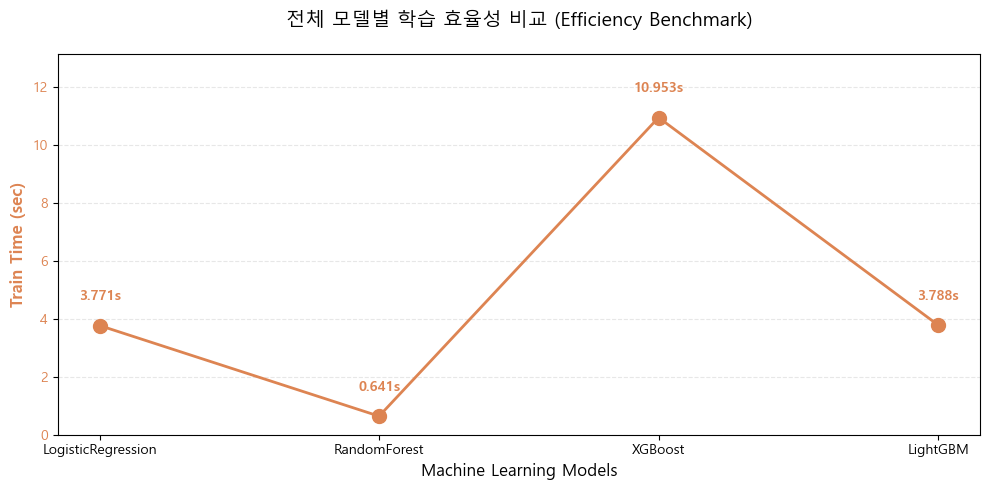

In [10]:
# 모델 비교 차트 (Scikit-learn 2종 + 부스팅 2종 총 4개 모델)
if not results or len(results) < 4:
    print(f"[알림] 현재 결과값이 {len(results)}개입니다. 4개 모델이 모두 학습되었는지 확인하세요.")

results_df = pd.DataFrame(results)

# 시각화 설정
fig_mc, ax1 = plt.subplots(figsize=(10, 5))

# 학습 시간 라인 그래프 (4개 포인트 연결)
ax1.plot(results_df["model"], results_df["train_time_sec"], 
         color="#DD8452", marker="o", linewidth=2, markersize=10, label="Train Time")

ax1.set_ylabel("Train Time (sec)", color="#DD8452", fontsize=12, fontweight='bold')
ax1.set_xlabel("Machine Learning Models", fontsize=12)
ax1.tick_params(axis="y", labelcolor="#DD8452")

# 각 점 위에 시간 수치 표시
for i, v in enumerate(results_df["train_time_sec"]):
    ax1.text(i, v + (results_df["train_time_sec"].max() * 0.07), f"{v:.3f}s", 
             ha="center", va="bottom", color="#DD8452", fontweight='bold', fontsize=10)

plt.title("전체 모델별 학습 효율성 비교 (Efficiency Benchmark)", fontsize=14, pad=20)
plt.grid(True, axis='y', linestyle='--', alpha=0.3)
plt.ylim(0, results_df["train_time_sec"].max() * 1.2) # 상단 여백 확보
plt.tight_layout()

# 2. 모델별 학습 시간 비교 차트 저장 
# (4개 모델 비교 차트 코드 마지막 부분에 추가)
mc_path = FIG_DIR / "model_comparison_train_time.png"
plt.savefig(mc_path, dpi=200, bbox_inches="tight")
print(f"✅ 모델 비교 차트 저장 완료: {mc_path}")

# 이미지 저장
mc_path = FIG_DIR / "full_model_comparison_time.png"
fig_mc.savefig(mc_path, dpi=200, bbox_inches="tight")
plt.show()